# modol

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
API_key = os.getenv("GOOGLE_API_KEY")
llm_model = "gemini-2.5-flash"

In [3]:
os.environ["LANGCHAIN_PROJECT"] = "Memory store"

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [5]:
model = ChatGoogleGenerativeAI(
                    model=llm_model,
                    temperature=0,
                    timeout=None,
                    max_retries=2)

# Goal

- These long-term memories will be used to create a personalized chatbot that can remember facts about the user.
- It will save memory "in the hot path", as the user is chatting with it.

# store 

In [6]:
import uuid
from langgraph.store.memory import InMemoryStore
in_memory_store = InMemoryStore() 

In [7]:
# Namespace for the memory to save
user_id = "1"
namespace_for_memory = (user_id, "memories")

In [8]:
# Save a memory to namespace as key and value
key = str(uuid.uuid4())

In [9]:
print(key)

e18e0901-d4ee-4492-9603-231c3e0b149d


In [10]:
# The value needs to be a dictionary  
value = {"food_preference" : "I like pizza"}

In [11]:
in_memory_store.put(namespace_for_memory, key, value)

In [12]:
print(in_memory_store)

```
{
  ("1", "memories"): {
    "a7a244e1-d405-4481-85fb-fe2ae886a2f5": {
      "food_preference": "I like pizza"
    }
  }
}
```

## search 

In [13]:
memories = in_memory_store.search(namespace_for_memory)
type(memories)

list

In [14]:
memories[0].dict()

{'namespace': ['1', 'memories'],
 'key': 'e18e0901-d4ee-4492-9603-231c3e0b149d',
 'value': {'food_preference': 'I like pizza'},
 'created_at': '2026-04-12T10:23:41.258967+00:00',
 'updated_at': '2026-04-12T10:23:41.258972+00:00',
 'score': None}

In [15]:
print(memories[0].key,"\n",memories[0].value)

e18e0901-d4ee-4492-9603-231c3e0b149d 
 {'food_preference': 'I like pizza'}


In [16]:
# Get the memory by namespace and key
memory = in_memory_store.get(namespace_for_memory, key)
memory.dict()

{'namespace': ['1', 'memories'],
 'key': 'e18e0901-d4ee-4492-9603-231c3e0b149d',
 'value': {'food_preference': 'I like pizza'},
 'created_at': '2026-04-12T10:23:41.258967+00:00',
 'updated_at': '2026-04-12T10:23:41.258972+00:00'}

# Chatbot with long-term memory

has two types of memory
- Short-term (within-thread) memory: Chatbot can persist conversational history and / or allow interruptions in a chat session.
- Long-term (cross-thread) memory: Chatbot can remember information about a specific user across all chat sessions.
- for short-term we use **checkpointer**
- for long-term memory we use **LangGraph Store**
- The chat history will be saved to short-term memory using the checkpointer.
- The chatbot will reflect on the chat history.
- It will then create and save a memory to the LangGraph Store.
- This memory is accessible in future chat sessions to personalize the chatbot's responses.

In [17]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.store.base import BaseStore # store 

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables.config import RunnableConfig

In [18]:
# Chatbot instruction
MODEL_SYSTEM_MESSAGE = """You are a helpful assistant with memory that provides information about the user. 
If you have memory for this user, use it to personalize your responses.
Here is the memory (it may be empty): {memory}"""

In [19]:
CREATE_MEMORY_INSTRUCTION = """
You are collecting information about the user to personalize future responses.

CURRENT USER INFORMATION:
{memory}

INSTRUCTIONS:
1. Review only the user's messages
2. Extract explicit facts stated by the user
3. Include:
   - Name
   - Location
   - Interests and hobbies
   - Food preferences
   - Activity-related preferences
4. Preserve useful details even if they seem small
5. Merge with existing memory
6. Return only a bulleted list

Do not include assistant messages.
Do not omit food preferences.

Update the memory now.
"""

## model call 

In [20]:
def call_model(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Load memory from the store and use it to personalize the chatbot's response."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Retrieve memory from the store
    namespace = ("memory", user_id)
    key = "user_memory"
    existing_memory = store.get(namespace, key)

    # Extract the actual memory content if it exists and add a prefix
    if existing_memory:
        # Value is a dictionary with a memory key
        existing_memory_content = existing_memory.value.get('memory')
    else:
        existing_memory_content = "No existing memory found."

    # Format the memory in the system prompt
    system_msg = MODEL_SYSTEM_MESSAGE.format(memory=existing_memory_content)
    
    # Respond using memory as well as the chat history
    response = model.invoke([SystemMessage(content=system_msg)]+state["messages"])

    return {"messages": response}

In [21]:
def write_memory(state: MessagesState, config: RunnableConfig, store: BaseStore):
    user_id = config["configurable"]["user_id"]

    namespace = ("memory", user_id)
    existing_memory = store.get(namespace, "user_memory")

    if existing_memory:
        existing_memory_content = existing_memory.value.get("memory")
    else:
        existing_memory_content = "No existing memory found."

    system_msg = CREATE_MEMORY_INSTRUCTION.format(memory=existing_memory_content)

    human_messages = [
        m for m in state["messages"]
        if isinstance(m, HumanMessage)
    ]

    new_memory = model.invoke(
        [SystemMessage(content=system_msg)] + human_messages
    )

    key = "user_memory"
    print(new_memory.content)
    store.put(namespace, key, {"memory": new_memory.content})

# Build Graph 

In [22]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_node("write_memory", write_memory)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", "write_memory")
builder.add_edge("write_memory", END)

In [23]:
# Store for long-term (across-thread) memory
across_thread_memory = InMemoryStore()

# Checkpointer for short-term (within-thread) memory
within_thread_memory = MemorySaver()


In [24]:
# Compile the graph with the checkpointer fir and store
graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)

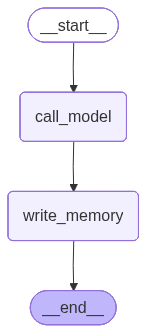

In [25]:
# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

# Test 

When we interact with the chatbot, we supply two things:
- Short-term (within-thread) memory: A thread ID for persisting the chat history.
- Long-term (cross-thread) memory: A user ID to namespace long-term memories to the user.

In [26]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory 
config = {"configurable": {"thread_id": "1", "user_id": "1"}}

In [27]:
# User input 
input_messages = [HumanMessage(content="Hi, my name is Lance")]

In [28]:
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Hi, my name is Lance
================================== Ai Message ==================================

Hi Lance, it's great to meet you!
* Name: Lance


In [29]:
# User input 
input_messages = [HumanMessage(content="I like to bike around San Francisco")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

I like to bike around San Francisco
================================== Ai Message ==================================

That's fantastic, Lance! San Francisco has some incredible (and challenging!) biking routes. Do you have a favorite spot to ride, or are you always looking for new trails to explore?
*   Name: Lance
*   Location: San Francisco
*   Interests and hobbies: Biking


In [30]:
thread = {"configurable": {"thread_id": "1"}}
state = graph.get_state(thread).values
for m in state["messages"]: 
    m.pretty_print()

================================ Human Message =================================

Hi, my name is Lance
================================== Ai Message ==================================

Hi Lance, it's great to meet you!
================================ Human Message =================================

I like to bike around San Francisco
================================== Ai Message ==================================

That's fantastic, Lance! San Francisco has some incredible (and challenging!) biking routes. Do you have a favorite spot to ride, or are you always looking for new trails to explore?


In [31]:
# Namespace for the memory to save
user_id = "1"
namespace = ("memory", user_id)
existing_memory = across_thread_memory.get(namespace, "user_memory")
existing_memory.dict()

{'namespace': ['memory', '1'],
 'key': 'user_memory',
 'value': {'memory': '*   Name: Lance\n*   Location: San Francisco\n*   Interests and hobbies: Biking'},
 'created_at': '2026-04-12T10:23:48.557172+00:00',
 'updated_at': '2026-04-12T10:23:48.557174+00:00'}

- Now, let's kick off a new thread with the same user ID.

In [32]:
# We supply a user ID for across-thread memory as well as a new thread ID
config = {"configurable": {"thread_id": "2", "user_id": "1"}}

# User input 
input_messages = [HumanMessage(content="Hi! Where would you recommend that I go biking?")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Hi! Where would you recommend that I go biking?
================================== Ai Message ==================================

Hi Lance! Since you're in San Francisco and love biking, you've got some fantastic options right at your doorstep.

Here are a few recommendations, depending on what kind of ride you're looking for:

1.  **Golden Gate Bridge & Sausalito:** This is a classic for a reason! You can bike across the Golden Gate Bridge, enjoy incredible views, and then coast down into Sausalito. From there, you can either bike back or take the ferry back to San Francisco with your bike. It's mostly flat once you're on the bridge, with a nice downhill into Sausalito.
2.  **Golden Gate Park:** If you're looking for a more relaxed ride without car traffic, Golden Gate Park is perfect. Many of the main roads are closed to cars on Sundays (and some on Saturdays), making it a cyclist's paradise. You can ex